In [62]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from transformers import pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch

In [63]:
aggresive = False

if aggresive:
    csv_path = "../data/topic/topics_aggressive.csv"
else:
    csv_path = "../data/topic/topics_light.csv"

df = pd.read_csv(csv_path)

In [64]:
y = df["label"].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # 'neutral', 'positive', 'negative'

print(y[:5])
print(y.dtype)

print("\n",y_encoded[:5])
print(y_encoded.dtype)

['neutral' 'neutral' 'negative' 'positive' 'positive']
object

 [1 1 0 2 2]
int32


In [65]:
topics  = df["topic"].values

print(topics)
print(topics.dtype)

[46 69 47 ... 95  5  5]
int64


In [66]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],  # se lo usavi
    random_state=42        # stesso seed usato prima
)

In [67]:
def evaluate_model_hf(y_true_labels, y_pred_labels, split_name="Test"):
    """
    Valuta le performance di un modello Hugging Face su un dataset e stampa le metriche + matrice di confusione.
    """
    print(f"\n--- {split_name} Results ---")
    print(classification_report(y_true_labels, y_pred_labels, digits=4))

    # === METRICHE GLOBALI ===
    acc = accuracy_score(y_true_labels, y_pred_labels)
    precision = precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    # === CONFUSION MATRIX ===
    unique_labels = sorted(set(y_true_labels) | set(y_pred_labels))  # Unione di predetti e reali
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=unique_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{split_name} Confusion Matrix")
    plt.show()

## Inferenza Diretta, senza fine-tuning e allenamento

In [68]:
device = 0 if torch.cuda.is_available() else -1
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 2060


In [ ]:
def evaluate_hf_model(test_texts, model_name="yiyanghkust/finbert-tone"):
    """
    Esegue inferenza su un test set con un modello HF pre-addestrato e calcola le metriche.
    """
    # 1. Crea pipeline di sentiment analysis
    hf_pipeline = pipeline(
        "sentiment-analysis",
        model=model_name,
        device=device,
        batch_size=16
    )

    # 2. Esegui inferenza
    predictions = hf_pipeline(test_texts.tolist(), truncation=True)

    # 3. Estrai etichette predette
    y_pred = [pred["label"].lower() for pred in predictions]  # es. "POSITIVE" → "positive"

    #evaluate_model_hf(y_test, y_pred, split_name="Test")

    return y_pred


In [ ]:
def evaluate_multiple_hf_models(model_names, X_test_raw, y_test):
    """
    Esegue inferenza e valutazione su più modelli Hugging Face e salva le metriche in un DataFrame/CSV.
    
    :param model_names: lista di modelli Hugging Face (str)
    :param X_test_raw: lista o pandas Series di testi grezzi
    :param y_test: lista o Series delle label vere
    :param save_csv_path: se specificato, salva il CSV con i risultati
    :return: DataFrame con metriche
    """
    results = []

    for model_name in model_names:
        try:
            print(f"\n➡️  Eseguendo inferenza con: {model_name}")
            y_pred = evaluate_hf_model(X_test_raw, model_name=model_name)

            acc = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
            recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
            f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

            results.append({
                "model": model_name,
                "accuracy": acc,
                "precision": precision,
                "recall": recall,
                "f1_score": f1
            })
        except Exception as e:
            print(f"❌ Errore con il modello: {model_name}")
            print(f"   {type(e).__name__}: {e}")

    df_results = pd.DataFrame(results)

    return df_results


In [71]:
hf_models = [
    "mrm8488/deberta-v3-ft-financial-news-sentiment-analysis",
    "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis",
    "soleimanian/financial-roberta-large-sentiment",
    "yiyanghkust/finbert-tone",
    "ProsusAI/finbert"
]

hf_results_df = evaluate_multiple_hf_models(hf_models, X_test_raw, y_test)


➡️  Eseguendo inferenza con: mrm8488/deberta-v3-ft-financial-news-sentiment-analysis


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



➡️  Eseguendo inferenza con: mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis


Device set to use cuda:0



➡️  Eseguendo inferenza con: soleimanian/financial-roberta-large-sentiment


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



➡️  Eseguendo inferenza con: yiyanghkust/finbert-tone


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



➡️  Eseguendo inferenza con: ProsusAI/finbert


Device set to use cuda:0


In [72]:
pd.set_option('display.width', 1000)

sorted_results = hf_results_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
print(sorted_results)

                                               model  accuracy  precision    recall  f1_score
0  mrm8488/deberta-v3-ft-financial-news-sentiment...  0.989680   0.989450  0.989450  0.989450
1                                   ProsusAI/finbert  0.882353   0.851867  0.907860  0.875420
2  mrm8488/distilroberta-finetuned-financial-news...  0.853457   0.844990  0.835670  0.840134
3                           yiyanghkust/finbert-tone  0.786378   0.792026  0.723432  0.743643
4      soleimanian/financial-roberta-large-sentiment  0.780186   0.785462  0.846567  0.792854


In [88]:
results_folder = "../training_results/"

if aggresive:
    results_pth = os.path.join(results_folder, "pretrained_aggresive.csv")
else:
    results_pth = os.path.join(results_folder, "pretrained_light.csv")

sorted_results.to_csv(results_pth, index=False)

In [84]:
def plot_results_summary(results_df, metric="f1_score"):
    """
    Crea un grafico a barre orizzontali con ordinamento decrescente, colori arcobaleno,
    e visualizzazione del valore percentuale al termine della barra.
    
    :param results_df: DataFrame contenente le colonne:
        - 'embedding'
        - 'model'
        - 'use_topic'
        - metrica (default: 'f1_score')
    :param metric: La metrica da visualizzare (default: 'f1_score')
    """
    # Colonna descrittiva
    results_df["label"] = (
        results_df["model"]
    )

    # Ordina per metrica in ordine decrescente
    results_df = results_df.sort_values(by=metric, ascending=False).reset_index(drop=True)

    # Colori arcobaleno
    cmap = plt.get_cmap("rainbow")
    colors = [cmap(i / len(results_df)) for i in range(len(results_df))]

    # Plot
    plt.figure(figsize=(14, 8))
    bars = plt.barh(results_df["label"], results_df[metric], color=colors)

    # Aggiungi etichette con valori percentuali alla fine delle barre
    for bar, value in zip(bars, results_df[metric]):
        plt.text(
            bar.get_width() + 0.005,   # posizione x (leggermente oltre la barra)
            bar.get_y() + bar.get_height() / 2,  # posizione y centrata
            f"{value*100:.2f}%",       # valore in percentuale
            va='center', ha='left', fontsize=9
        )

    # Etichette e stile
    plt.xlabel(metric.replace("_", " ").title())
    plt.title(f"Confronto tra Modelli Pre-addestrati HF – {metric.replace('_', ' ').title()}")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.xlim(right=results_df[metric].max() + 0.1)
    plt.show()


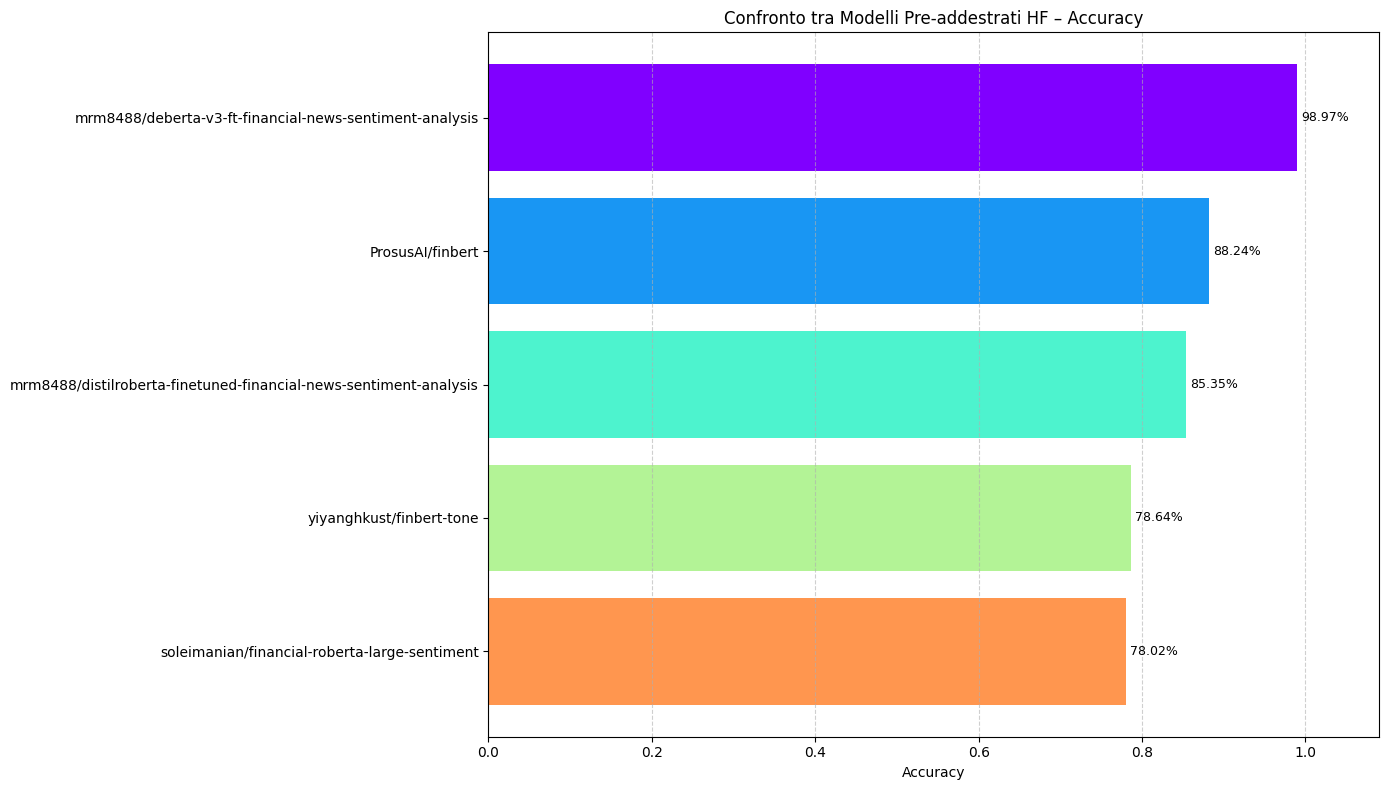

In [85]:
plot_results_summary(sorted_results, metric="accuracy")

Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



--- Test Results ---
              precision    recall  f1-score   support

    negative     0.9917    0.9917    0.9917       121
     neutral     0.9913    0.9913    0.9913       576
    positive     0.9853    0.9853    0.9853       272

    accuracy                         0.9897       969
   macro avg     0.9894    0.9894    0.9894       969
weighted avg     0.9897    0.9897    0.9897       969

Accuracy:  0.9897
Precision: 0.9894
Recall:    0.9894
F1 Score:  0.9894


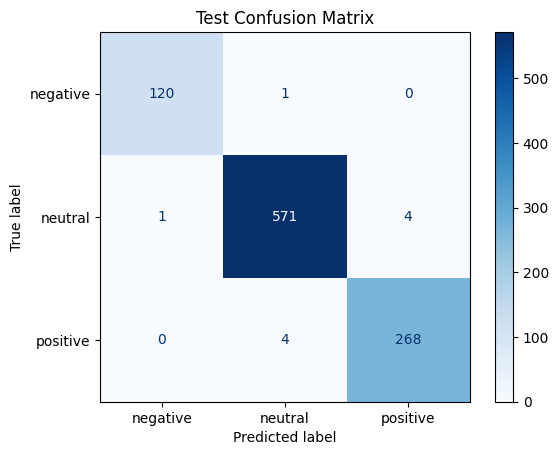

In [ ]:
best_model_row = sorted_results.iloc[0]
best_model = best_model_row["model"]
print(f"best model: {best_model}")

y_pred = evaluate_hf_model(X_test_raw, y_test, model_name=best_model)
evaluate_model_hf(y_test, y_pred, split_name="Test")

In [97]:
errors_df = pd.DataFrame({
    "text": X_test_raw,
    "true_label": y_test,
    "predicted_label": y_pred
})

# Filtra solo gli errori
misclassified = errors_df[errors_df["true_label"] != errors_df["predicted_label"]]

pd.set_option('display.max_colwidth', None)
print(misclassified.head(5))

                                                                                                                                    text true_label predicted_label
511                               The company plans to spend the proceeds from the rights offering for strengthening its balance sheet .    neutral        positive
1122                                              ` For Nordea , moving into the new headquarters signifies the beginning of a new era .   positive         neutral
4124                                                          Outokumpu 's steel mill in Tornio , in Finland , is the suspected source .   negative         neutral
2250  Under the agreement Ponsse will provide forest machine maintenance services to Stora Enso 's Russian wood procurement operations .    neutral        positive
3571                                                                     Earnings per share EPS in 2005 amounted to a loss of EUR1 .26 .    neutral        negative
